# wavesst — Full Pipeline Demo

End-to-end walkthrough of every transform in the library on two crossing chirps.

**Pipeline:** Signal synthesis → CWT → SST → MSST → STFT → STFT-SST → Ridge extraction → Reconstruction

All plots are interactive (requires ipywidgets ≥ 8.0 and a Jupyter environment).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import wavesst
from wavesst.viz.interactive import (
    iplot_cwt, iplot_sst, iplot_ridges,
    iplot_stft, iplot_stft_sst, iplot_components,
)

%matplotlib inline
print(f'wavesst {wavesst.__version__}')

wavesst 0.1.0


## 1 — Signal Synthesis

Two crossing chirps:
- **Linear chirp:** 20 → 100 Hz over 2 s
- **Quadratic chirp:** 120 → 30 Hz over 2 s

Both have unit amplitude; the signal is a simple sum.

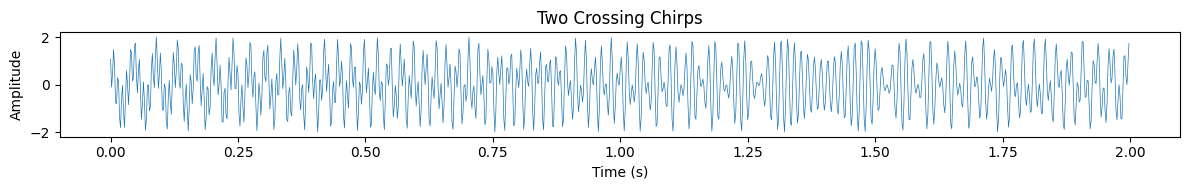

In [2]:
FS = 512.0
T  = 2.0
t  = np.arange(int(T * FS)) / FS
N  = len(t)

# Linear chirp: 20 -> 100 Hz
f_lin  = 20 + 80 * t / T
chirp1 = np.cos(2 * np.pi * np.cumsum(f_lin) / FS)

# Quadratic chirp: 120 -> 30 Hz
f_quad = 120 - 90 * (t / T) ** 2
chirp2 = np.cos(2 * np.pi * np.cumsum(f_quad) / FS)

x = (chirp1 + chirp2).astype(np.float32)

fig, ax = plt.subplots(figsize=(12, 2))
ax.plot(t, x, lw=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title('Two Crossing Chirps')
plt.tight_layout()
plt.show()

## 2 — Config

In [3]:
cfg = wavesst.Config(device='auto', dtype='complex64')
print(cfg)

Config(dtype=torch.complex64, device='auto', vram_budget_gb=None, chunk_scales=None, safety_factor=0.75)


## 3 — CWT

Morlet CWT with 32 voices per octave.

In [4]:
cwt_result = wavesst.cwt(x, fs=FS, nv=32, cfg=cfg)
print(f'CWT shape: {cwt_result.W.shape}  freqs: {cwt_result.freqs[0]:.1f}–{cwt_result.freqs[-1]:.1f} Hz')
iplot_cwt(cwt_result)

CWT shape: torch.Size([288, 1024])  freqs: 244.5–0.5 Hz


Output()

## 4 — SST

Synchrosqueezed CWT — energy is reassigned to the estimated instantaneous frequency.

In [5]:
sst_result = wavesst.sst(x, fs=FS, nv=32, gamma='auto', cfg=cfg)
print(f'SST shape: {sst_result.Tx.shape}')
iplot_sst(sst_result)

SST shape: torch.Size([288, 1024])


Output()

## 5 — MSST (3 iterations)

Multi-synchrosqueezing progressively sharpens the TF plane.

In [6]:
# True Pham-Meignen MSST: passes 2+ use Tx-derived IF estimator
msst_result = wavesst.msst(x, fs=FS, nv=32, n_iter=3, gamma='auto', cfg=cfg)
print(f'MSST shape: {msst_result.Tx.shape}  n_iter={msst_result.n_iter}')
iplot_sst(msst_result)

MSST shape: torch.Size([288, 1024])  n_iter=3


Output()

## 6 — Ridge Extraction

Dynamic-programming ridge tracker on the SST plane.

In [7]:
ridges = wavesst.extract_ridges(sst_result, n=2, penalty=2.0)
for i, r in enumerate(ridges):
    print(f'Ridge {i+1}: median freq = {np.median(r.freq_path):.1f} Hz,  energy = {r.energy:.2e}')
iplot_ridges(sst_result, ridges)

Ridge 1: median freq = 111.0 Hz,  energy = 5.02e+01
Ridge 2: median freq = 76.1 Hz,  energy = 1.24e+01


Output()

## 7 — Reconstruction (CWT-SST)

Admissibility-constant inverse: `x_k(t) = (2/C_ψ) · Re[ Σ_{f ∈ band_k} T_x(f, t) ]`.

In [8]:
components = wavesst.reconstruct(sst_result, ridges)
iplot_components(components, sst_result.times)

Output()

## 8 — STFT

In [9]:
stft_result = wavesst.stft(x, fs=FS, nperseg=256, noverlap=240, cfg=cfg)
print(f'STFT shape: {stft_result.V.shape}')
iplot_stft(stft_result)

STFT shape: torch.Size([129, 49])


Output()

## 9 — STFT-SST

In [10]:
stft_sst_result = wavesst.stft_sst(x, fs=FS, nperseg=256, noverlap=240, gamma='auto', cfg=cfg)
print(f'STFT-SST shape: {stft_sst_result.Tx.shape}')
iplot_stft_sst(stft_sst_result)

STFT-SST shape: torch.Size([129, 49])


Output()

## 10 — Reconstruction (STFT-SST)

Overlap-add synthesis on the raw STFT V at the ridge bin.

In [11]:
stft_ridges = wavesst.extract_ridges(stft_sst_result, n=2, penalty=2.0)
stft_comps  = wavesst.reconstruct(stft_sst_result, stft_ridges, fs=FS)
iplot_components(stft_comps, t)

Output()

## 11 — Inverse CWT (icwt) — Bandpass Denoising

`icwt()` reconstructs a time-domain signal from a `CWTResult` using the admissibility formula:

$$x(t) = \frac{da\_ratio}{K_\psi} \cdot \operatorname{Re}\!\left[\sum_a W(a,t)\right]$$

With optional `f_low`/`f_high`, you can zero out scales outside a band before reconstructing — a simple but effective bandpass denoising approach.

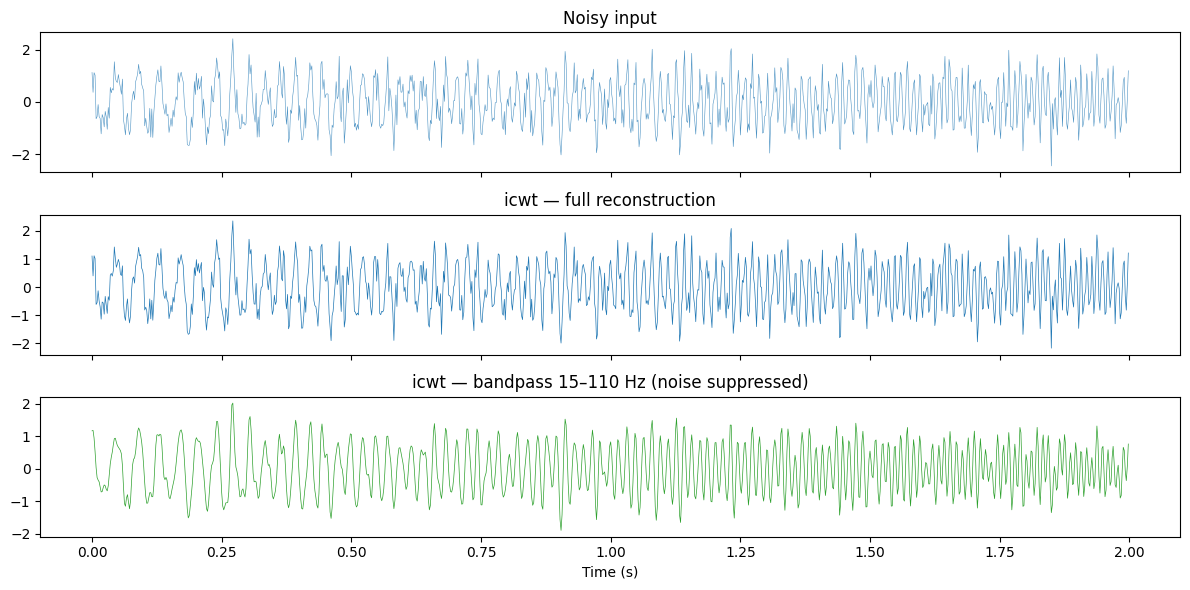

Full reconstruction error (RMS): 0.1004 (relative)


In [12]:
# Synthesise: clean chirp + broadband noise
rng = np.random.default_rng(42)
t_demo = np.arange(int(2.0 * FS)) / FS
f_sweep = 20 + 80 * t_demo / 2.0
chirp_clean = np.cos(2 * np.pi * np.cumsum(f_sweep) / FS).astype(np.float32)
noisy = (chirp_clean + 0.5 * rng.standard_normal(len(chirp_clean)).astype(np.float32))

# CWT of the noisy signal (CPU cfg to keep it simple)
cfg_cpu = wavesst.Config(device='cpu', dtype='complex64')
cwt_noisy = wavesst.cwt(noisy, fs=FS, nv=32, cfg=cfg_cpu)

# icwt: full reconstruction
x_full = wavesst.icwt(cwt_noisy)

# icwt: bandpass (keep only 15–110 Hz)
x_band = wavesst.icwt(cwt_noisy, f_low=15.0, f_high=110.0)

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t_demo, noisy, lw=0.4, alpha=0.8)
axes[0].set_title('Noisy input')
axes[1].plot(t_demo, x_full, lw=0.5)
axes[1].set_title('icwt — full reconstruction')
axes[2].plot(t_demo, x_band, lw=0.5, color='C2')
axes[2].set_title('icwt — bandpass 15–110 Hz (noise suppressed)')
axes[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

rms_input = float(np.sqrt(np.mean(noisy**2)))
rms_err   = float(np.sqrt(np.mean((x_full - noisy.astype(np.float64))**2)))
print(f'Full reconstruction error (RMS): {rms_err/rms_input:.4f} (relative)')